# 1-Librairies

In [1]:
# Dataset
import kagglehub

# Standard libraries
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# tensorflow libraries
import tensorflow as tf
from tensorflow.keras import callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# keras libraries
from keras.optimizers import Adam

# scikit-learn libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Suppression des warnings
import warnings
warnings.filterwarnings("ignore")

c:\Users\mgraz\Documents\.vscode\Alyra\Projet Alyra\Block 5 - Deep Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2-Dataset

In [2]:
# Téléchargement du dataset depuis Kaggle
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Chemin d'accés du dossier du Dataset:", path)

# Classification des images de tumeurs cérébrales
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
# Affichage des noms de classes
print("Class names:", class_names)

# Convertir les noms de classes en binaire
# Ici, nous considérons 'notumor' comme 'Sain' et les autres comme 'Tumeur'
binary_class_names = ['Sain' if name == 'notumor' else 'Tumeur' for name in class_names]

# Affichage des noms de classes binaires
binary_class_names = dict(zip(class_names, binary_class_names))
print("Binary class names:", binary_class_names)

Chemin d'accés du dossier du Dataset: C:\Users\mgraz\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\1
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Binary class names: {'glioma': 'Tumeur', 'meningioma': 'Tumeur', 'notumor': 'Sain', 'pituitary': 'Tumeur'}


## 2.1-Dataset Entrainement

In [3]:
# Création de train_df à partir du dossier Training
train_images = []
train_binary_class_names = []

# Parcours des images dans le dossier Training
train_dir = os.path.join(path, 'Training')
for category in binary_class_names:
	category_path = os.path.join(train_dir, category)
	for img_name in os.listdir(category_path):
		train_images.append(os.path.join(category_path, img_name))
		train_binary_class_names.append(binary_class_names[category])
# Affichage du nombre d'images dans le dataset d'entraînement
print("Nombre d'images dans le dataset d'entraînement:", len(train_images))
# Création du DataFrame train_df
train_df = pd.DataFrame({"image_path": train_images, "label": train_binary_class_names})

X_train = train_df["image_path"].values
y_train = train_df["label"].values

print("Nombre d'images par classes dans le dataset de validation:", train_df['label'].value_counts())

Nombre d'images dans le dataset d'entraînement: 5712
Nombre d'images par classes dans le dataset de validation: label
Tumeur    4117
Sain      1595
Name: count, dtype: int64


## 2.2-Dataset Test

In [4]:
# Création de test_df à partir du dossier Testing
test_images = []
test_binary_class_names = []

# Parcours des images dans le dossier Testing
test_dir = os.path.join(path, 'Testing')
for category in class_names:
	category_path = os.path.join(test_dir, category)
	for img_name in os.listdir(category_path):
		test_images.append(os.path.join(category_path, img_name))
		test_binary_class_names.append(binary_class_names[category])

# Affichage du nombre d'images dans le dataset d'entraînement
print("Nombre d'images dans le dataset d'entraînement:", len(test_images))
# Création du DataFrame train_df
test_df = pd.DataFrame({"image_path": test_images, "label": test_binary_class_names})

X_test = test_df["image_path"].values
y_test = test_df["label"].values

print("Nombre d'images par classes dans le dataset de validation:", test_df['label'].value_counts())

Nombre d'images dans le dataset d'entraînement: 1311
Nombre d'images par classes dans le dataset de validation: label
Tumeur    906
Sain      405
Name: count, dtype: int64


## 2.3-Dataset de Validation

In [ ]:
# Creation d'un dataset de validation
X_train, X_val, y_train, y_val = train_test_split(
    train_df["image_path"].to_numpy(),
    train_df["label"].to_numpy(),
    train_size=0.7,  # 70% des données pour l'entraînement
    test_size=0.3,   # 30% des données pour la validation
    random_state=42,
    stratify=train_df["label"],
)
val_df = pd.DataFrame({'image_path': X_val, 'label': y_val})

# Affichage du nombre d'images par classes dans le dataset de validation
print("Nombre d'images par classes dans le dataset de validation:", val_df['label'].value_counts())

Nombre d'images par classes dans le dataset de validation: label
Tumeur    1235
Sain       479
Name: count, dtype: int64


# 3-Preprocessing

## 3.1-Paramêtres

In [6]:
# Creation des hyperparamètres
def create_params():
    return {
        'batch_size': 32,  # Taille du batch
        'image_size': (128, 128),  # Taille des images pour Resnet50
        'input_shape': (128, 128, 3),  # Forme d'entrée pour les images RGB
        'epochs': 20,  # Nombre d'époques pour l'entraînement
        'learning_rate': 0.001,  # Taux d'apprentissage pour l'optimiseur
    }

params = create_params()

## 3.2-Séparation des classes du dataset d'entrainement

In [7]:
# Filtrage des images 'Sain' dans le DataFrame train_df
notumor_df = train_df[train_df['label'] == 'Sain']

# Filtrage des images 'Tumeur' dans le DataFrame train_df
tumor_df = train_df[train_df['label'] == 'Tumeur']

# Affichage du nombre d'images dans le DataFrame filtré
print("Nombre d'images 'Sain':", len(notumor_df))
print("Nombre d'images 'Tumeur':", len(tumor_df))

Nombre d'images 'Sain': 1595
Nombre d'images 'Tumeur': 4117


## 3.3-ImageDataGenerator

In [8]:
# sans augmentation pour la classe majoritaire
tumor_df_datagen = ImageDataGenerator(rescale=1./255)

# avec augmentation pour la classe minoritaire
notumor_df_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)


## 3.4-Création des générateurs

In [9]:
print ("Générateur ")

# Générateurs
tumor_gen = tumor_df_datagen.flow_from_dataframe(
    dataframe=tumor_df,
    x_col='image_path',
    y_col='label',
    target_size=params['image_size'],
    batch_size=params['batch_size'],
    class_mode=None
)

notumor_gen = notumor_df_datagen.flow_from_dataframe(
    dataframe=notumor_df,
    x_col='image_path',
    y_col='label',
    target_size=params['image_size'],
    batch_size=params['batch_size'],
    class_mode=None
)

val_datagen = ImageDataGenerator(rescale=1./255)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=params['image_size'],
    batch_size=params['batch_size'],
    class_mode='binary',
    shuffle=False
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=params['image_size'],
    batch_size=params['batch_size'],
    class_mode='binary',
    shuffle=False
)

Générateur 
Found 4117 validated image filenames.
Found 1595 validated image filenames.
Found 1714 validated image filenames belonging to 2 classes.
Found 1311 validated image filenames belonging to 2 classes.


## 3.5-Générateur équilibré

In [10]:
def balanced_generator(gen_tumor, gen_notumor, batch_size):
    half_batch = batch_size // 2
    while True:
        X_tumor = next(gen_tumor)[:half_batch]
        X_notumor = next(gen_notumor)[:half_batch]

        y_tumor = np.ones((half_batch, 1))
        y_notumor = np.zeros((half_batch, 1))

        X_batch = np.concatenate([X_tumor, X_notumor], axis=0)
        y_batch = np.concatenate([y_tumor, y_notumor], axis=0)

        indices = np.arange(batch_size)
        np.random.shuffle(indices)

        yield X_batch[indices], y_batch[indices]

# 4-Modèle CNN ResNet50

## 4.1- Chargement du modèle ResNet50

In [11]:
# Chargement du modèle de base
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=params['input_shape'])

# Analyse des couches de Resnet50
print("Analyse des couches de ResNet50:")
print(f"Nombre total de couches: {len(base_model.layers)}")

# Afficher quelques couches pour comprendre la structure
print("\nStructure des couches (dernières 20):")
for i, layer in enumerate(base_model.layers[-20:]):
    print(f"   {len(base_model.layers)-10+i:3d}: {layer.name} ({layer.__class__.__name__})")

Analyse des couches de ResNet50:
Nombre total de couches: 175

Structure des couches (dernières 20):
   165: conv5_block2_1_conv (Conv2D)
   166: conv5_block2_1_bn (BatchNormalization)
   167: conv5_block2_1_relu (Activation)
   168: conv5_block2_2_conv (Conv2D)
   169: conv5_block2_2_bn (BatchNormalization)
   170: conv5_block2_2_relu (Activation)
   171: conv5_block2_3_conv (Conv2D)
   172: conv5_block2_3_bn (BatchNormalization)
   173: conv5_block2_add (Add)
   174: conv5_block2_out (Activation)
   175: conv5_block3_1_conv (Conv2D)
   176: conv5_block3_1_bn (BatchNormalization)
   177: conv5_block3_1_relu (Activation)
   178: conv5_block3_2_conv (Conv2D)
   179: conv5_block3_2_bn (BatchNormalization)
   180: conv5_block3_2_relu (Activation)
   181: conv5_block3_3_conv (Conv2D)
   182: conv5_block3_3_bn (BatchNormalization)
   183: conv5_block3_add (Add)
   184: conv5_block3_out (Activation)


## 4.2- Phase 1 : Transfer Learning

### 4.2.1-Création du modèle  avec les couches gelées

In [12]:
# Gel des couches du modèle de base (Transfer Learning)
base_model.trainable = False

# Couche d'entrée
inputs = tf.keras.Input(params['input_shape'])

x = base_model(inputs, training=False) # Modèle de base gelé
# Pooling global pour réduire les dimensions
x = tf.keras.layers.GlobalAveragePooling2D()(x)
# Couche de dropout pour la régularisation
x = tf.keras.layers.Dropout(0.5)(x)
# Ajouter nouvelle couche de classification
x = tf.keras.layers.Dense(128, activation='relu')(x)  # Couche dense avec 128 neurones et activation ReLU

# Couche de sortie
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x) # Couche de classification finale

# Création du modèle final
model = tf.keras.Model(inputs, outputs)

### 4.2.2-Compilation du modèle avec couche gelées

In [13]:
# Compilation des modeles
def compile_model(model):
    compile_config = {
        'optimizer': Adam(learning_rate=params['learning_rate']),
        'loss': 'binary_crossentropy',  # Utilisation de 'binary_crossentropy' pour la classification binaire
        'metrics': ['accuracy', 'Precision', 'Recall']
    }
    model.compile(**compile_config)
    return model
cnn_model_resnet50 = compile_model(model)

print("\n=== ARCHITECTURE CNN - ResNet50 ===")
cnn_model_resnet50.summary()


=== ARCHITECTURE CNN - ResNet50 ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### 4.2.3-CallBacks

In [14]:
def create_callbacks():
    callbacks_phase1 = [

        # Sauvegarde du meilleur modèle
        callbacks.ModelCheckpoint(
            './models/resnet50_phase1.keras',
            monitor='val_loss',
            save_best_only=True,
        ),

        # Early stopping pour éviter l'overfitting
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
        )
    ]
    return callbacks_phase1

callbacks_phase1 = create_callbacks()

### 4.2.4-Entraînement du modèle CNN Resnet50 avec couche gelée

In [15]:
print("=== Début de l'entraînement Phase 1===")

batch_size = params['batch_size']
train_gen = balanced_generator(tumor_gen, notumor_gen, batch_size)
steps_per_epoch = min(len(tumor_gen), len(notumor_gen)) * 2
validation_steps = len(val_gen)

history_tr = cnn_model_resnet50.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=params['epochs'],
    callbacks=callbacks_phase1,
    verbose=1,
    )

print("=== Entraînement Phase 1 terminé ===")

=== Début de l'entraînement Phase 1===
Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 741ms/step - Precision: 0.6015 - Recall: 0.6209 - accuracy: 0.6051 - loss: 0.6526 - val_Precision: 0.8977 - val_Recall: 0.9304 - val_accuracy: 0.8734 - val_loss: 0.4304
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 68s 682ms/step - Precision: 0.7110 - Recall: 0.8336 - accuracy: 0.7472 - loss: 0.5261 - val_Precision: 0.9475 - val_Recall: 0.8040 - val_accuracy: 0.8267 - val_loss: 0.4814
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 67s 669ms/step - Precision: 0.7200 - Recall: 0.7990 - accuracy: 0.7439 - loss: 0.5055 - val_Precision: 0.9466 - val_Recall: 0.8615 - val_accuracy: 0.8652 - val_loss: 0.4179
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 68s 678ms/step - Precision: 0.7726 - Recall: 0.8225 - accuracy: 0.7893 - loss: 0.4586 - val_Precision: 0.9340 - val_Recall: 0.9053 - val_accuracy: 0.8856 - val_loss: 0.3472
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 65s 648ms/step - Precision: 0.7604 - Recall: 0.8493 - accuracy: 0.790

## 4.4-Phase 2 : Fine-Tuning

### 4.4.1-Gel/Dégel des couches du modèle

In [16]:
# Stratégie de dégel : dégeler les 10 dernières couches
fine_tune_at = len(base_model.layers) - 10

print(f"\nStratégie de dégel:")
print(f"Couches 0 à {fine_tune_at-1}: GELÉES (features génériques)")
print(f"Couches {fine_tune_at} à {len(base_model.layers)-1}: DÉGELÉES (features spécifiques)")

# Application du dégel
print("Application de la stratégie de dégel...")

# Dégeler le modèle de base
base_model.trainable = True

# Geler les premières couches, dégeler les dernières
for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False  # Garder gelé
    else:
        layer.trainable = True   # Dégeler

# Compter les paramètres entraînables
trainable_params = sum(tf.size(var).numpy() for var in model.trainable_variables)
total_params = model.count_params()

print("Dégel appliqué !")
print(f"Paramètres entraînables: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"Paramètres gelés: {total_params-trainable_params:,} ({(total_params-trainable_params)/total_params*100:.1f}%)")
print(f"Total: {total_params:,} paramètres")


Stratégie de dégel:
Couches 0 à 164: GELÉES (features génériques)
Couches 165 à 174: DÉGELÉES (features spécifiques)
Application de la stratégie de dégel...
Dégel appliqué !
Paramètres entraînables: 4,728,065 (19.8%)
Paramètres gelés: 19,122,048 (80.2%)
Total: 23,850,113 paramètres


### 4.4.2-Recompilation du Modèle

In [17]:
# Recompilation avec learning rate réduit
fine_tune_lr = params['learning_rate'] / 10  # Diviser par 10

print(f"Recompilation du modèle pour le fine-tuning...")
print(f"Nouveau learning rate: {fine_tune_lr} (10x plus faible)")

# Compilation du modele
def compile_model(model):
    compile_config = {
        'optimizer': Adam(learning_rate=fine_tune_lr),
        'loss': 'binary_crossentropy',  # Utilisation de 'binary_crossentropy' pour la classification binaire
        'metrics': ['accuracy', 'Precision', 'Recall']
    }
    model.compile(**compile_config)
    return model
cnn_model_resnet50 = compile_model(model)


print("Modèle recompilé !")

Recompilation du modèle pour le fine-tuning...
Nouveau learning rate: 0.0001 (10x plus faible)
Modèle recompilé !


### 4.4.3_Callbacks

In [18]:
def create_callbacks():
    callbacks_phase2 = [

        # Sauvegarde du meilleur modèle
        callbacks.ModelCheckpoint(
            './models/resnet50_phase2.keras',
            monitor='val_loss',
            save_best_only=True,
        ),

        # Early stopping pour éviter l'overfitting
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True,
        )
    ]
    return callbacks_phase2

callbacks_phase2 = create_callbacks()

### 4.4.4-Entrainement du modele recompilé

In [19]:
print("=== PHASE 2: FINE-TUNING (couches dégelées) ===")
print("\nDébut du fine-tuning...")

# Continuer l'entraînement depuis la dernière époque
initial_epoch = len(history_tr.history['accuracy'])
total_epochs = initial_epoch + params['epochs']

print(f"Reprendre depuis l'époque: {initial_epoch}")
print(f"Aller jusqu'à l'époque: {total_epochs}")
print(f"Époque supplémentaires: {params['epochs']}")

# Fine-tuning
history_fine = cnn_model_resnet50.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=total_epochs,
    initial_epoch=initial_epoch,
    callbacks=callbacks_phase2,
    verbose=1
)

print("\nFine-tuning terminé !")
print(f"Époques totales effectuées: {len(history_tr.history['accuracy']) + len(history_fine.history['accuracy'])}")
print(f"Précision finale d'entraînement: {history_fine.history['accuracy'][-1]:.4f}")
print(f"Précision finale de validation: {history_fine.history['val_accuracy'][-1]:.4f}")

=== PHASE 2: FINE-TUNING (couches dégelées) ===

Début du fine-tuning...
Reprendre depuis l'époque: 12
Aller jusqu'à l'époque: 32
Époque supplémentaires: 20
Epoch 13/32
100/100 ━━━━━━━━━━━━━━━━━━━━ 84s 776ms/step - Precision: 0.8156 - Recall: 0.7668 - accuracy: 0.8063 - loss: 1.4819 - val_Precision: 0.7214 - val_Recall: 1.0000 - val_accuracy: 0.7217 - val_loss: 1.8303
Epoch 14/32
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 754ms/step - Precision: 0.9207 - Recall: 0.9215 - accuracy: 0.9211 - loss: 0.2255 - val_Precision: 0.7205 - val_Recall: 1.0000 - val_accuracy: 0.7205 - val_loss: 1.5905
Epoch 15/32
100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 743ms/step - Precision: 0.9390 - Recall: 0.9361 - accuracy: 0.9376 - loss: 0.1752 - val_Precision: 0.7391 - val_Recall: 1.0000 - val_accuracy: 0.7456 - val_loss: 0.9232
Epoch 16/32
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 748ms/step - Precision: 0.9399 - Recall: 0.9569 - accuracy: 0.9477 - loss: 0.1558 - val_Precision: 0.8282 - val_Recall: 0.9992 - val_accuracy: 0.8501 - val_

## 4.5-Visualisation de l'entrainement

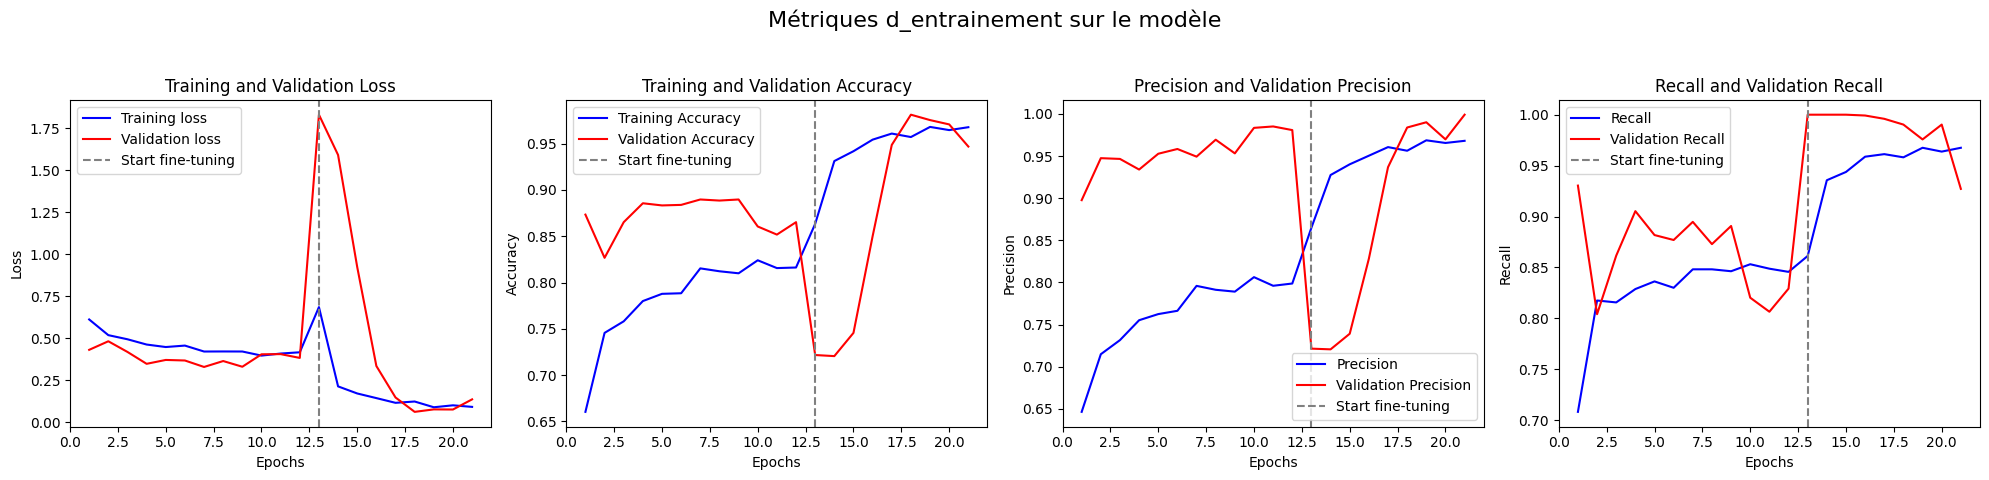

In [20]:
# Fusionner les deux phases pour les tracer ensemble
loss = history_tr.history["loss"] + history_fine.history["loss"]
acc = history_tr.history["accuracy"] + history_fine.history["accuracy"]
per = history_tr.history['Precision'] + history_fine.history['Precision']
recall = history_tr.history['Recall'] + history_fine.history['Recall']

val_loss = history_tr.history["val_loss"] + history_fine.history["val_loss"]
val_acc = history_tr.history["val_accuracy"] + history_fine.history["val_accuracy"]
val_per = history_tr.history['val_Precision'] + history_fine.history['val_Precision']
val_recall = history_tr.history['val_Recall'] + history_fine.history['val_Recall']

epochs = range(1, len(loss) + 1)
fine_tune_at = len(history_tr.history["loss"]) + 1

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'

# Graphique
fig, ax = plt.subplots(ncols=4, figsize=(20, 5))

# Affichage des métriques de la perte

ax[0].plot(epochs, loss, 'b-', label='Training loss')
ax[0].plot(epochs, val_loss, 'r-', label='Validation loss')
ax[0].axvline(x=fine_tune_at, color='gray', linestyle='--', label='Start fine-tuning')
ax[0].set_title('Training and Validation Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Affichage des métriques de accuracy

ax[1].plot(epochs, acc, 'b-', label='Training Accuracy')
ax[1].plot(epochs, val_acc, 'r-', label='Validation Accuracy')
ax[1].axvline(x=fine_tune_at, color='gray', linestyle='--', label='Start fine-tuning')
ax[1].set_title('Training and Validation Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

# Affichage des métriques de précision

ax[2].plot(Epochs, per, 'b-', label='Precision')
ax[2].plot(Epochs, val_per, 'r-', label='Validation Precision')
ax[2].axvline(x=fine_tune_at, color='gray', linestyle='--', label='Start fine-tuning')
ax[2].set_title('Precision and Validation Precision')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Precision')
ax[2].legend()

# Affichage des métriques de rappel

ax[3].plot(Epochs, recall, 'b-', label='Recall')
ax[3].plot(Epochs, val_recall, 'r-', label='Validation Recall')
ax[3].axvline(x=fine_tune_at, color='gray', linestyle='--', label='Start fine-tuning')
ax[3].set_title('Recall and Validation Recall')
ax[3].set_xlabel('Epochs')
ax[3].set_ylabel('Recall')
ax[3].legend()

plt.suptitle('Métriques d_entrainement sur le modèle', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4.6-Evaluation des modèles

41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 459ms/step

=== Phase 1 (Transfert) ===
Accuracy: 0.8207 | Loss: 0.4533 | Precision: 0.9168 | Recall: 0.8146

Classification report :
              precision    recall  f1-score   support

           0       0.67      0.83      0.74       405
           1       0.92      0.81      0.86       906

    accuracy                           0.82      1311
   macro avg       0.79      0.82      0.80      1311
weighted avg       0.84      0.82      0.83      1311

Matrice de confusion :
[[338  67]
 [168 738]]
41/41 ━━━━━━━━━━━━━━━━━━━━ 21s 476ms/step

=== Phase 2 (Fine-tuning) ===
Accuracy: 0.9619 | Loss: 0.1042 | Precision: 0.9787 | Recall: 0.9658

Classification report :
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       405
           1       0.98      0.97      0.97       906

    accuracy                           0.96      1311
   macro avg       0.95      0.96      0.96      1311
weighted avg       0.96

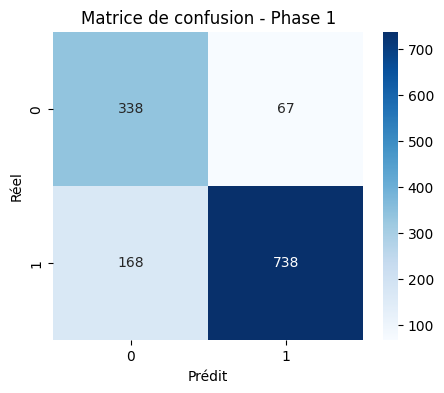

41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 434ms/step


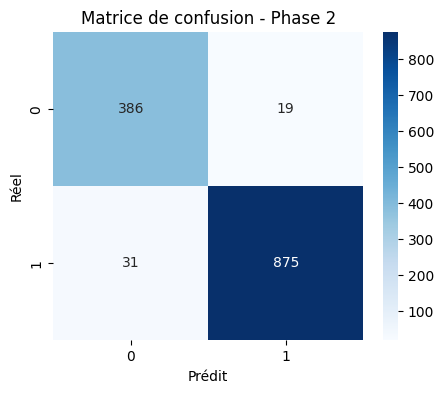

In [21]:
resnet50_phase1 = load_model('./models/resnet50_phase1.keras')
resnet50_phase2 = load_model('./models/resnet50_phase2.keras')

def evaluate_model(model, test_gen, name=""):
    # Prédictions
    preds = model.predict(test_gen)
    y_pred = (preds > 0.5).astype(int)
    y_true = test_gen.classes

    # Scores
    loss, acc, precision, recall = model.evaluate(test_gen, verbose=0)
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f} | Loss: {loss:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}\n")

    # Rapport de classification
    print("Classification report :")
    print(classification_report(y_true, y_pred))

    # Matrice de confusion
    print("Matrice de confusion :")
    print(confusion_matrix(y_true, y_pred))

# Évaluer les deux modèles
evaluate_model(resnet50_phase1, test_gen, name="Phase 1 (Transfert)")
evaluate_model(resnet50_phase2, test_gen, name="Phase 2 (Fine-tuning)")


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matrice de confusion - {title}")
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.show()

# Phase 1
preds1 = (resnet50_phase1.predict(test_gen) > 0.5).astype(int)
plot_confusion_matrix(test_gen.classes, preds1, title="Phase 1")

# Phase 2
preds2 = (resnet50_phase2.predict(test_gen) > 0.5).astype(int)
plot_confusion_matrix(test_gen.classes, preds2, title="Phase 2")

# 5-Prédictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step


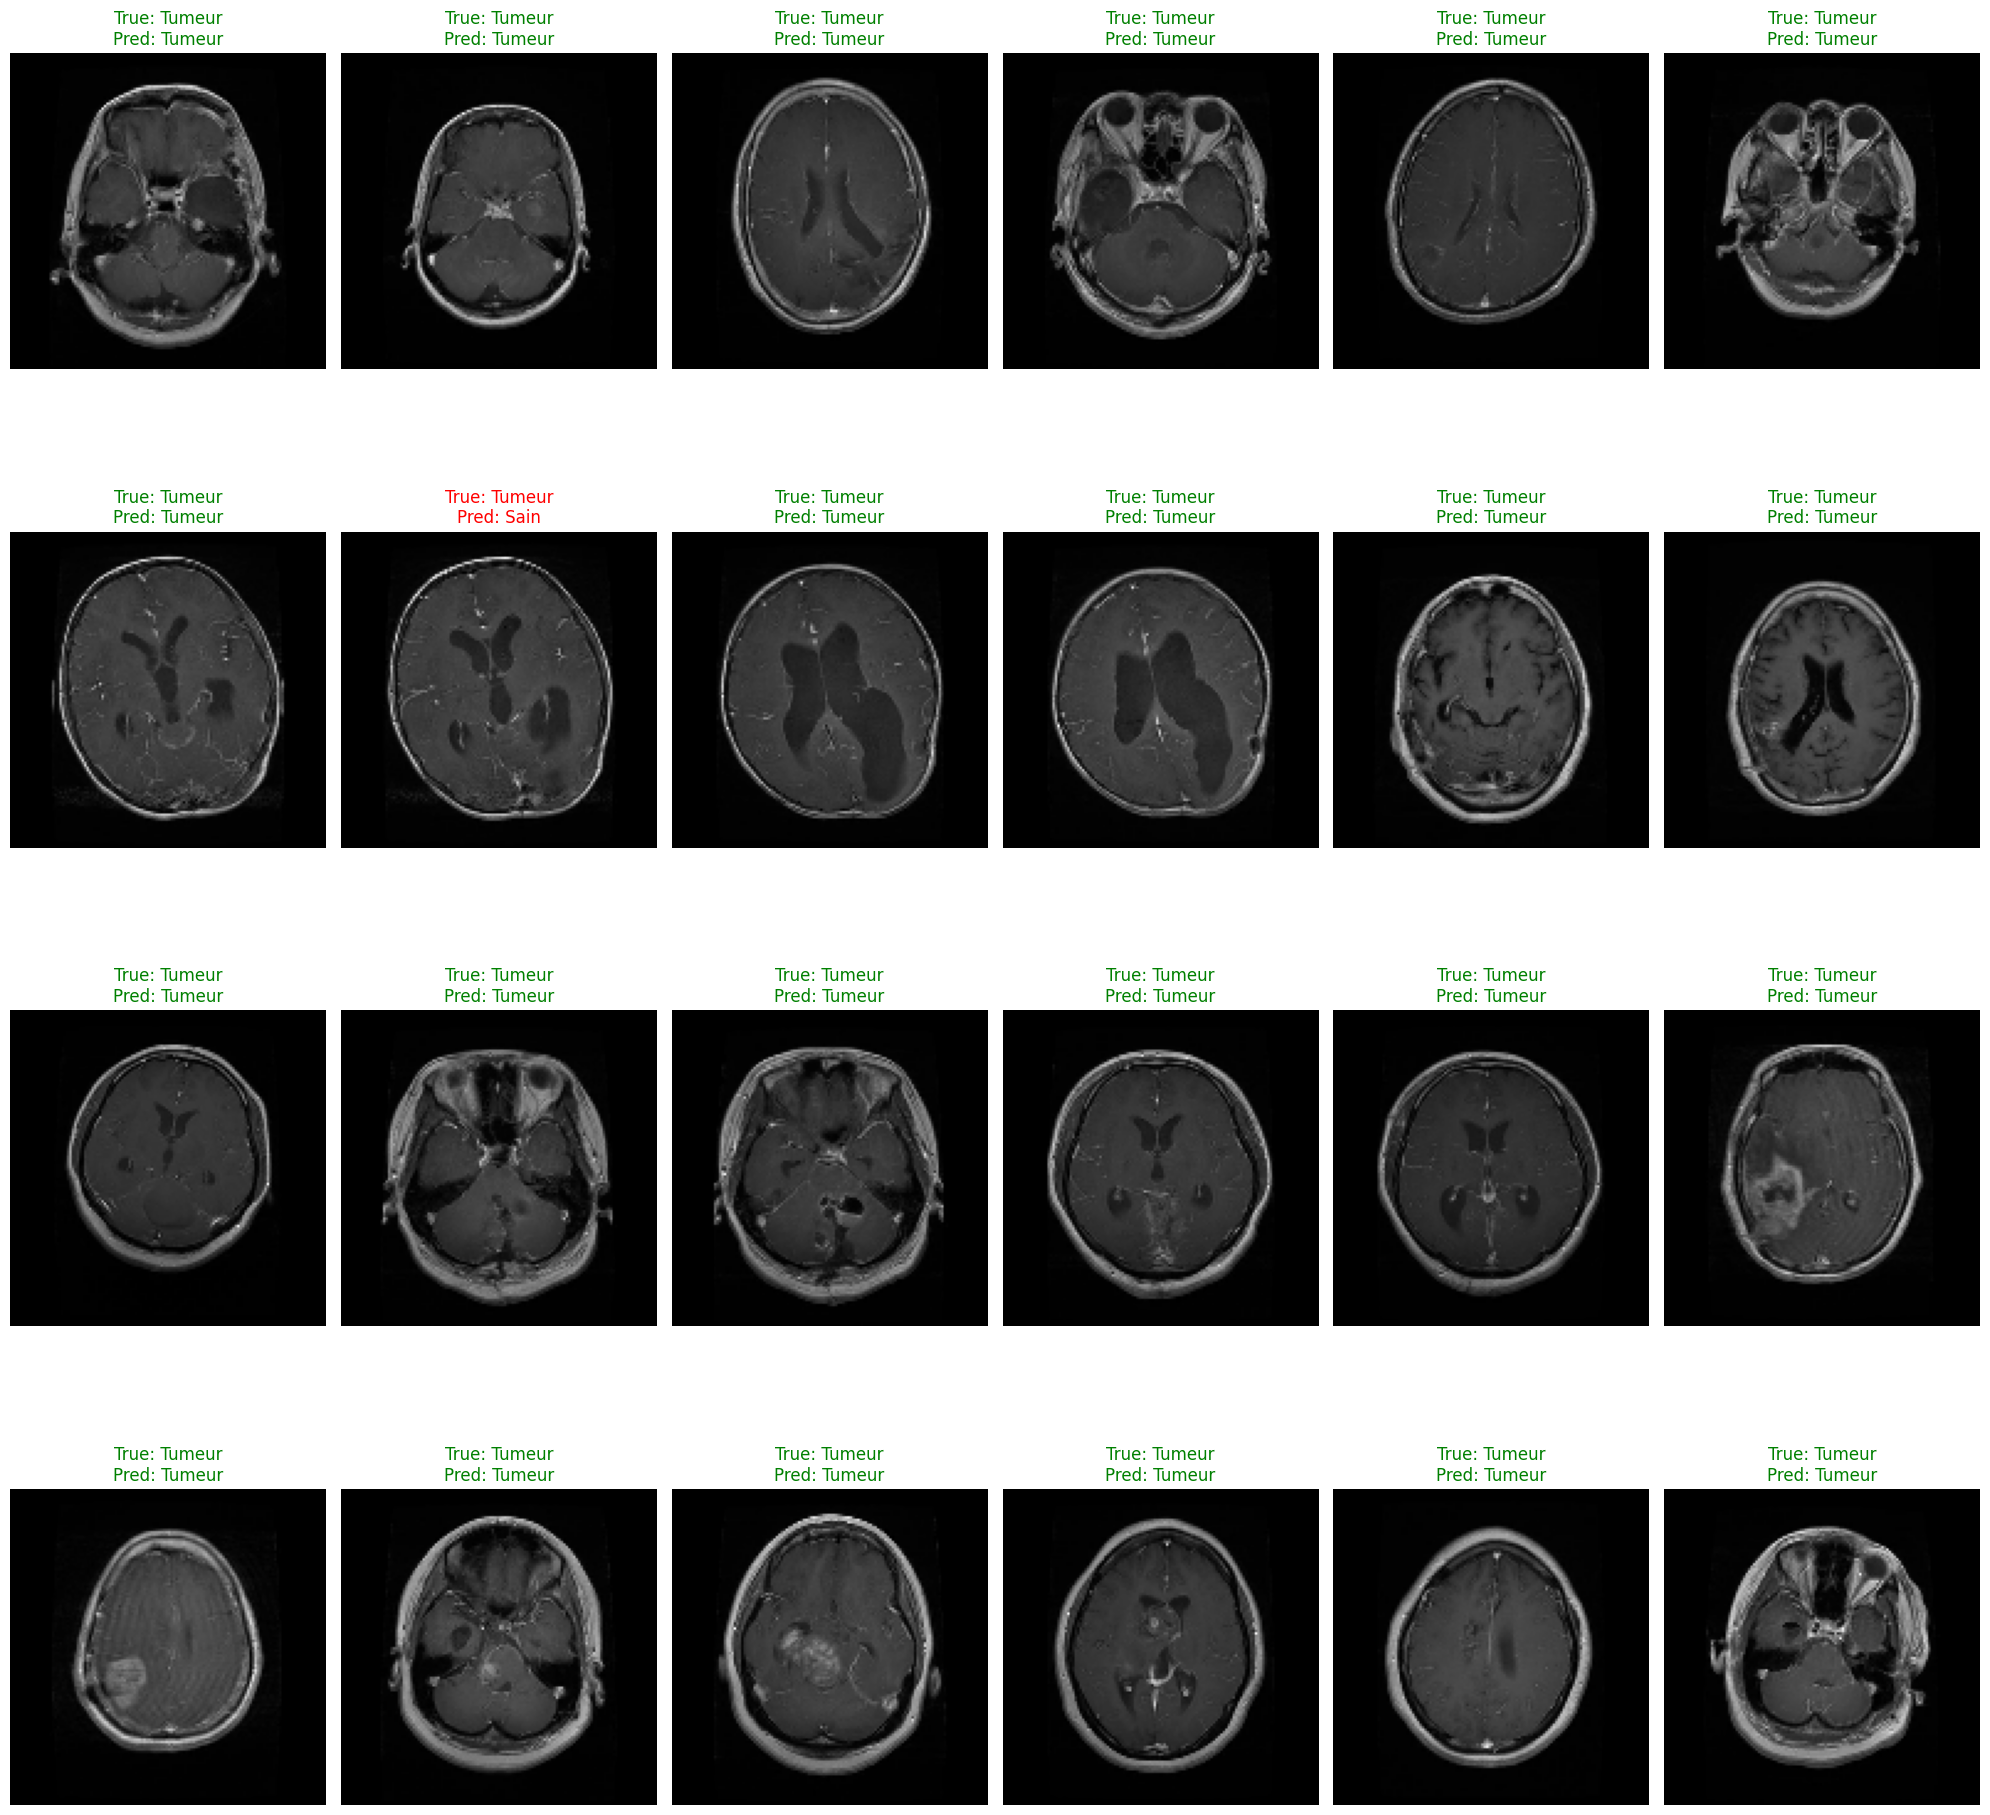

In [25]:
# Visualisation des prédictions sur un échantillon d'images du dataset de test

# Definir la fonction predictions
def predictions(model, test_generator, num_samples=20, figsize=(20, 20)):
    plt.figure(figsize=figsize)
    rows = int(np.floor(np.sqrt(num_samples)))
    cols = int(np.ceil(num_samples / rows))

    # Get a batch of images and true binary labels from the test generator
    images, true_labels_encoded = next(test_generator)
    # The true_labels_encoded from the generator with class_mode='binary' are already 0s and 1s
    true_labels = ['Tumeur' if label == 1 else 'Sain' for label in true_labels_encoded.flatten()]


    # Obtenir les predictions du modèle
    predictions_probs = model.predict(images)
    predicted_labels_encoded = (predictions_probs > 0.5).astype(int).flatten()
    predicted_labels = ['Tumeur' if label == 1 else 'Sain' for label in predicted_labels_encoded]

    batch_len = min(num_samples, len(images)) # Utiliser la longueur du batch
    for i in range(batch_len):
        plt.subplot(rows, cols, i + 1)
        # Afficher l'image
        plt.imshow(images[i])
        true_label = true_labels[i]
        predicted_label = predicted_labels[i]
        color = "green" if true_label == predicted_label else "red"
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

try:
    # Use the fine-tuned model for predictions
    cnn_model_to_use = resnet50_phase2 # Use the loaded phase 2 model
except NameError:
    print("Erreur : 'resnet50_phase2' n'est pas défini. Veuillez exécuter la cellule où le modèle est chargé.")
else:
    # Use the test_gen for predictions visualization as it provides batches with labels
    predictions(model=cnn_model_to_use,
                test_generator=test_gen, # Use the test_gen
                num_samples=24,
                figsize=(20, 20))